# Customer Segmentation and Validation

## Objective

The objective of this notebook is to identify natural customer segments based on the Customer Priority Score developed in the previous notebook.

Instead of defining customer categories manually, clustering techniques are used to discover the underlying structure of the data.

The resulting customer segments are then validated using a supervised machine learning model to evaluate whether the identified groups are meaningful and distinguishable.

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import RandomForestClassifier

In [23]:


df = pd.read_csv("../data/customer_priority_dataset.csv")



In [24]:
df = pd.read_csv("../data/customer_priority_dataset.csv")

df.head()

,Customer_ID,Bandwidth_Mbps,Price_Per_Mbps,Monthly_Internet_Fee,Years_With_Company,Customer_Type,Company_Size,Strategic_Category,Strategic_Level,Has_VoIP,...,Downtime_Hours_Last_Year,Contract_Type,Total_Monthly_Revenue,Number_of_Services,High_Value,Revenue_Score,Strategic_Score,Services_Score,Company_Size_Score,Customer_Priority_Score
0,C00006,100,285000,28500000,8.0,Business,Medium,Small Business,1,0,...,2.8,Annual,28500000.0,1,0,17.924412,26.0,27.5,26.2,22.217206
1,C00007,100,280000,28000000,2.8,Business,Small,Small Business,1,1,...,3.4,Monthly,28453701.0,2,0,17.891611,26.0,35.6,25.8,23.355805
2,C00008,100,265000,26500000,8.3,Business,Small,Small Business,1,1,...,6.1,Monthly,27280519.0,2,0,17.060441,26.0,35.6,25.8,22.940220
3,C00012,100,250000,25000000,6.4,Business,Small,Small Business,1,0,...,3.6,Annual,25000000.0,1,0,15.444751,26.0,27.5,25.8,20.917375
4,C00014,300,200000,60000000,5.5,Government,Large,Government,3,0,...,7.9,Annual,60000000.0,1,1,40.241369,63.6,27.5,56.8,45.485684


## 2. Customer Priority Score Distribution

### Objective

Before performing clustering, the distribution of the Customer Priority Score is examined to understand whether natural groupings may exist within the data.

This analysis provides an initial indication of the overall score distribution before applying clustering algorithms.

### Observation

The Customer Priority Score follows a continuous distribution without predefined customer categories.

Visual inspection alone is insufficient to determine the optimal number of customer segments. Therefore, clustering evaluation techniques will be used in the next section to identify the natural grouping structure of the data.

## 3. Finding the Optimal Number of Clusters

### Objective

The number of customer segments should not be selected arbitrarily.

To identify the most appropriate number of clusters, the Elbow Method is applied by evaluating the Within-Cluster Sum of Squares (WCSS) for different values of *k*.

The optimal number of clusters is expected to occur near the point where adding more clusters produces only marginal improvements.

In [25]:
X = df[["Customer_Priority_Score"]]

In [26]:
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

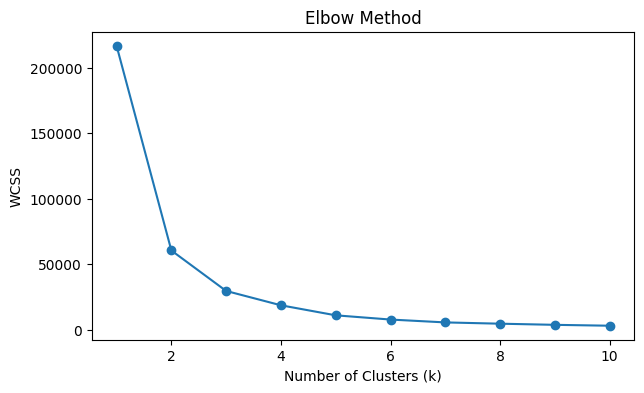

In [27]:
plt.figure(figsize=(7,4))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")

plt.show()

### Silhouette Analysis

#### Objective

While the Elbow Method evaluates the reduction in within-cluster variance, the Silhouette Score measures how well-separated the resulting clusters are.

The optimal number of clusters is selected by considering both methods together.

In [28]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

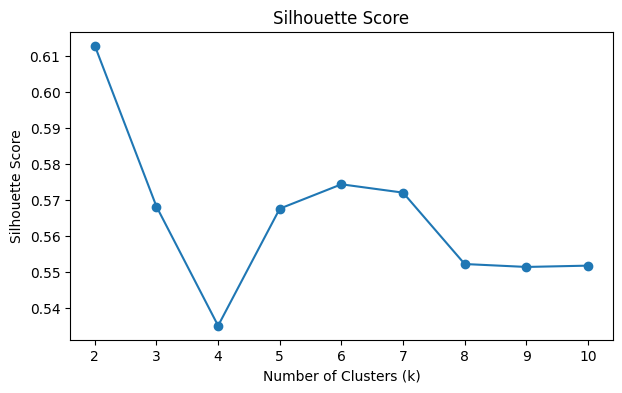

In [29]:
plt.figure(figsize=(7,4))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.show()

### Observation

The Elbow Method indicates a clear inflection point around **k = 3**, suggesting that three clusters capture most of the underlying data structure.

Although the highest Silhouette Score is achieved with **k = 2**, the score for **k = 3** remains relatively high while providing a more informative customer segmentation.

Considering both clustering quality and business interpretability, **three clusters** were selected for the subsequent customer segmentation analysis.

## 4. Customer Segmentation using K-Means

### Objective

Based on the results of the Elbow Method and the Silhouette Analysis, the customers are segmented into three clusters using the K-Means algorithm.

Each customer is assigned to the cluster with the nearest centroid based on the Customer Priority Score.

In [30]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

In [31]:
df["Cluster"].value_counts().sort_index()

Cluster
0    498
1    448
2    567
Name: count, dtype: int64

In [32]:
cluster_summary = (
    df.groupby("Cluster")["Customer_Priority_Score"]
      .agg(["count", "min", "mean", "max"])
      .round(2)
)

cluster_summary

,count,min,mean,max
Cluster,,,,
0,498,27.33,33.67,40.80
1,448,41.00,48.29,75.36
2,567,13.20,20.97,27.24


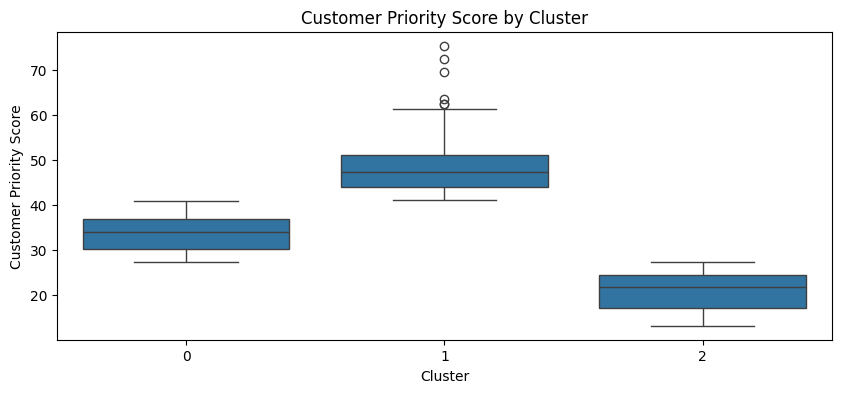

In [33]:
plt.figure(figsize=(10,4))

sns.boxplot(
    data=df,
    x="Cluster",
    y="Customer_Priority_Score"
)

plt.title("Customer Priority Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customer Priority Score")

plt.show()

In [34]:
cluster_names = {
    2: "Low Priority",
    0: "Medium Priority",
    1: "High Priority"
}

df["Customer_Segment"] = df["Cluster"].map(cluster_names)

In [35]:
df[["Cluster", "Customer_Segment"]].head()

,Cluster,Customer_Segment
0,2,Low Priority
1,2,Low Priority
2,2,Low Priority
3,2,Low Priority
4,1,High Priority


In [36]:
df["Customer_Segment"].value_counts()

Customer_Segment
Low Priority       567
Medium Priority    498
High Priority      448
Name: count, dtype: int64

### Observation

The K-Means algorithm identified three well-separated customer segments based on the Customer Priority Score.

The clusters represent customers with low, medium, and high business priority. The relatively balanced cluster sizes and clear separation of the score distributions indicate that the segmentation captures meaningful differences in customer value.

## 5. Cluster Validation using Random Forest

### Objective

To validate the discovered customer segments, a Random Forest classifier is trained to predict the cluster assignment using the engineered feature scores.

If the clusters can be accurately predicted, it indicates that the segmentation captures meaningful patterns in the customer data.

In addition, feature importance is analyzed to identify which scoring factors contribute the most to the segmentation.

In [37]:
X = df[
    [
        "Revenue_Score",
        "Strategic_Score",
        "Services_Score",
        "Company_Size_Score"
    ]
]

In [39]:
y = df["Cluster"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [42]:
accuracy = rf.score(X_test, y_test)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.997


### Observation

The Random Forest classifier achieved an accuracy of **99.7%** when predicting the customer clusters.

This extremely high accuracy indicates that the clusters generated by K-Means are highly distinguishable based on the engineered feature scores.

Therefore, the proposed customer scoring framework successfully captures meaningful differences between customer groups and provides a reliable basis for customer prioritization.

In [43]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
)

feature_importance

,Feature,Importance
0,Revenue_Score,0.539054
1,Strategic_Score,0.238488
3,Company_Size_Score,0.143399
2,Services_Score,0.079059


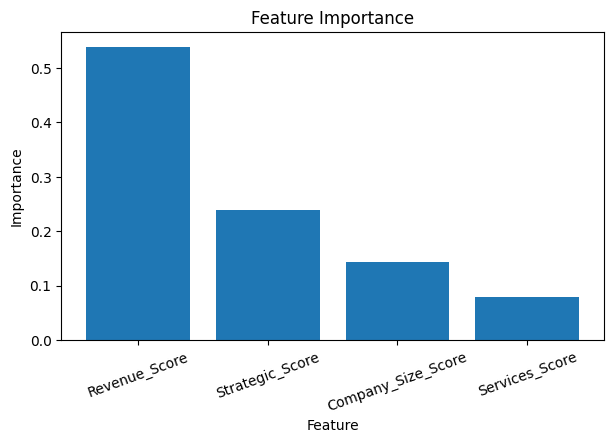

In [44]:
plt.figure(figsize=(7,4))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(rotation=20)

plt.show()

### Observation

Feature importance analysis shows that **Revenue Score** is the strongest contributor to customer segmentation, followed by **Strategic Score**.

The remaining two features contribute less to the clustering process, with **Company Size Score** having a slightly greater influence than **Services Score**.

Overall, the feature importance ranking is highly consistent with the business-defined weighting strategy proposed in the customer scoring framework, providing additional validation for the designed prioritization model.

# Conclusion

This notebook demonstrated that the proposed Customer Priority Score naturally separates customers into three meaningful business segments using K-Means clustering.

The selected number of clusters was supported by both the Elbow Method and the Silhouette Score, balancing clustering quality and business interpretability.

Furthermore, a Random Forest classifier achieved an accuracy of **99.7%**, confirming that the discovered customer segments are highly distinguishable based on the engineered feature scores.

Feature importance analysis further validated the proposed business scoring framework, showing that Revenue Score is the dominant factor, followed by Strategic Score, Company Size Score, and Services Score.

Overall, the proposed methodology provides an explainable, data-driven, and validated customer prioritization framework that can support business decision-making and customer relationship management.